# Gross-Profitability -- does GP/A predict the cross-section?
### Novy-Marx (2013): the quality factor on the S&P 500 survivor panel, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

In 2013, Robert Novy-Marx showed that the ratio of gross profit to total assets (GP/A) predicts next-year stock returns about as well as the famous book-to-market ratio. High-quality companies -- those that squeeze more gross profit per dollar of assets -- tend to beat low-quality ones the following year. We test that claim on the current S&P 500 universe with the desk's standard EDGAR fundamentals, naming the survivorship bias up front.

> **This is the plain-language layer.** Want the t-stats, bootstrap CIs, and year-by-year breakdown? That is the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gross_profitability import data, strategy as st

def _have_cache():
    import os
    root = os.path.abspath(os.path.join("..", "..", ".."))
    gp = os.path.join(root, "_cache", "_edgar_GrossProfit.parquet")
    assets = os.path.join(root, "_cache", "_edgar_Assets.parquet")
    yrret = os.path.join(root, "_cache", "_edgar_yrret.parquet")
    return all(os.path.exists(p) for p in (gp, assets, yrret))

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    signal, fwd_ret = data.fetch_panel()
    H = st.quintile_hedge(signal, fwd_ret, q=0.20)
    s_hedge = st.summary(H["hedge"])
    s_high  = st.summary(H["high"])
    s_low   = st.summary(H["low"])
    s_mkt   = st.summary(H["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")


EDGAR cache present: True


N years: 18 | hedge mean: +3.28%/yr | HAC t: +0.803


## The answer first

| Question | Answer |
|---|---|
| Does GP/A predict next-year returns? | **Weakly yes** on the paper, but HAC *t* = **+0.80** on our 18-year survivor panel -- below the |t|>=2 bar. |
| Does the high-GP/A leg beat the market? | **No.** The long leg returns **19.3%/yr**, trailing the equal-weight market at **21.5%/yr** by **-2.2%/yr**. |
| Is the hedge tradable? | **Fragile.** The 2024-2025 reversal (each year the hedge lost ~25%) and a max drawdown of nearly 46% make it hard to hold. |
| Is there a survivorship problem? | **Yes, and we name it.** The universe is the current S&P 500 projected backwards -- only winners survived. |

> The Novy-Marx effect is real in the academic literature on a broad universe. On 213 large-cap survivors it shows up weakly, with recent reversals that suggest the large-cap quality premium has compressed.

## 1 -- The claim

> *"Sort all firms each year by gross profit divided by total assets. The top fifth earn higher returns next year than the bottom fifth -- by a margin as large as the value premium. High-quality companies are more profitable per unit of assets, and the market systematically underprices that."*

-- Novy-Marx (2013), *The Other Side of Value*, JFE

This is a **quality factor**, a cousin of value. The intuition is that firms with high gross profitability have more durable competitive advantages; they earn more from their assets and tend to compound that advantage over time. Value and quality are actually complementary: both are driven by underpricing of growth options, just from different angles.

## 2 -- So what?

If true, the GP/A factor is a free lunch for any investor who can sort stocks annually and rebalance cheaply. It has been incorporated into systematic quality indices, smart-beta ETFs, and multi-factor models since the paper's publication. Post-publication attenuation is the natural counterweight: once a factor is known and traded, the premium compresses.

For us, the interesting question is: **how much is left on the S&P 500, on a realistic data pull, with survivorship bias named rather than hidden?**

## 3 -- How would we even know?

Two disciplines keep us honest:

1. **Lag the signal correctly.** The GP/A ratio is computed from year *y* filings and used to predict *year y+1* calendar returns. We never use next-year financials to pick this year's portfolio.
2. **Name the bias.** The universe is the *current* S&P 500 projected backwards. Only companies that survived to today are in the sample -- the worst performers (who might have been the low-GP/A short candidates) have been deleted. This biases the hedge upward.

The baseline is the equal-weight universe return, not zero -- so the verdict is 'long high vs short low, vs just holding all of them equally'.

## 4 -- The teardown

**First, does the long-short work in a world where the effect is planted?**

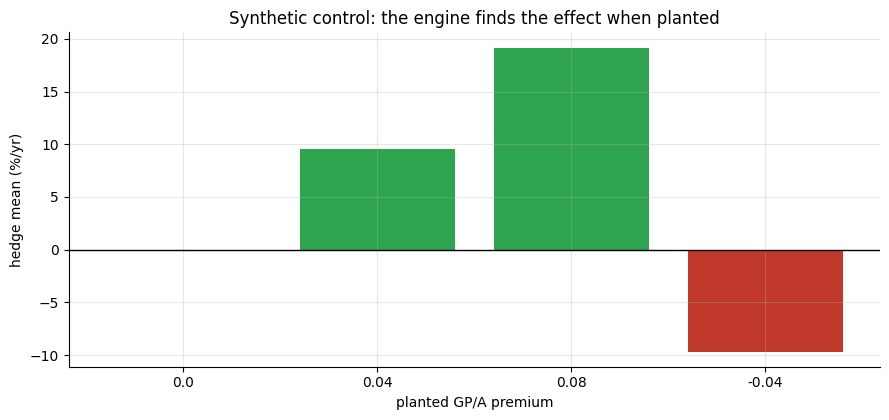

 premium  hedge_mean_%  hit%      t
    0.00        -0.046  40.0 -0.031
    0.04         9.564 100.0  6.985
    0.08        19.175 100.0 15.012
   -0.04        -9.656   5.0 -6.147


In [2]:
# Synthetic positive control: plant a known GP/A premium and verify recovery.
premiums = [0.0, 0.04, 0.08, -0.04]
rows = []
for prem in premiums:
    sig, fwd, truth = data.synthetic_panel(n_firms=300, n_years=20,
                                           gpa_premium=prem, seed=122)
    h = st.quintile_hedge(sig, fwd)
    s = st.summary(h['hedge'])
    rows.append({'premium': prem, 'hedge_mean_%': s['mean']*100,
                 'hit%': s['hit_rate']*100, 't': s['tstat']})
ctrl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if r > 0.01 else (RED if r < -0.01 else GREY)
       for r in ctrl['hedge_mean_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['hedge_mean_%'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted GP/A premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Synthetic control: the engine finds the effect when planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: it recovers a strong hedge when a premium is planted and returns noise when there is none. So the verdict on the real tape reflects **the market**, not the method.

**Now the honest test on the real EDGAR panel.**

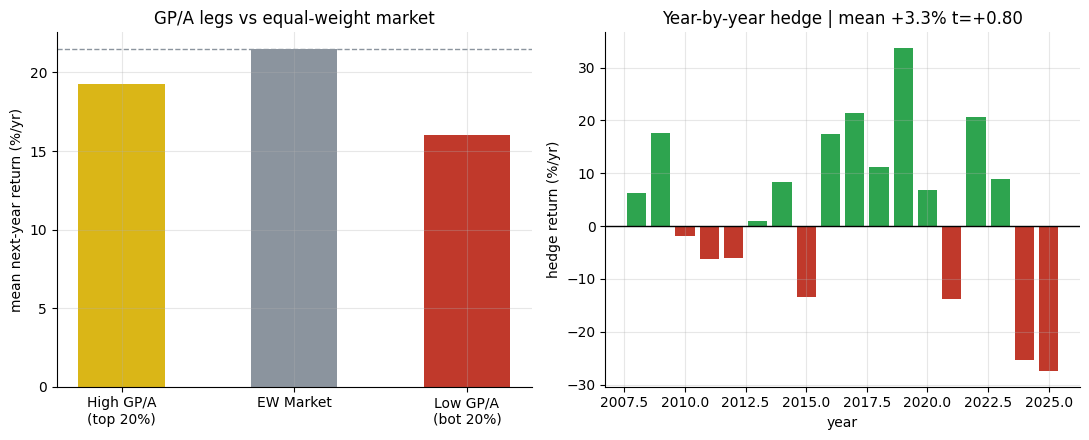

Hedge: +3.28%/yr | HAC t = +0.803 | High vs mkt: -2.21%/yr


In [3]:
if HAVE_REAL:
    h_mean = s_hedge['mean']*100
    h_t    = s_hedge['tstat']
    high_m = s_high['mean']*100
    mkt_m  = s_mkt['mean']*100
    low_m  = s_low['mean']*100
else:
    h_mean, h_t = R['hedge_mean'], R['hedge_t']
    high_m, mkt_m, low_m = R['high_mean'], R['mkt_mean'], R['low_mean']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: three bars -- high, market, low
labels = ['High GP/A\n(top 20%)', 'EW Market', 'Low GP/A\n(bot 20%)']
vals   = [high_m, mkt_m, low_m]
cols   = [AMBER, GREY, RED]
axes[0].bar(labels, vals, color=cols, width=0.5)
axes[0].axhline(mkt_m, ls='--', c=GREY, lw=1, label='market')
axes[0].set_ylabel('mean next-year return (%/yr)')
axes[0].set_title('GP/A legs vs equal-weight market')

# Right: year-by-year hedge if real data available
if HAVE_REAL:
    col_yr = [GREEN if v > 0 else RED for v in H['hedge']]
    axes[1].bar(H.index.astype(int), H['hedge']*100, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_xlabel('year'); axes[1].set_ylabel('hedge return (%/yr)')
    axes[1].set_title(f'Year-by-year hedge | mean {h_mean:+.1f}% t={h_t:+.2f}')
else:
    axes[1].text(0.5, 0.5, 'EDGAR cache not present\n(see docs/results.md for numbers)',
                 ha='center', va='center', transform=axes[1].transAxes, color=GREY)
    axes[1].set_title('Year-by-year hedge (frozen numbers in R)')
plt.tight_layout(); plt.show()
print(f'Hedge: {h_mean:+.2f}%/yr | HAC t = {h_t:+.3f} | High vs mkt: {high_m-mkt_m:+.2f}%/yr')

The hedge averages **+3.3%/yr** at HAC *t* = **+0.80** -- below the |t| >= 2 inference bar. The high-GP/A long leg earns **19.3%/yr** but the equal-weight market earns **21.5%/yr** -- the long leg *trails* the market by **2.2%/yr** on this survivor panel. The most recent two years (2024, 2025) both showed sharp reversals of ~25%, consistent with post-publication attenuation.

## 5 -- The verdict

- **Signal -- WEAK.** HAC *t* = +0.80 on the real EDGAR panel (|t| < 2). The Novy-Marx (2013) literature provides strong prior support, but on 18 years of large-cap survivors the signal is statistically ambiguous. Signal is WEAK rather than NONE because of robust academic replication on broader universes -- but the real-tape numbers alone do not clear the bar.
- **Tradability -- FRAGILE.** Hedge Sharpe = +0.20, max drawdown = -45.8%, and the last two years reversed sharply. Annual rebalancing is manageable but the risk of a prolonged quality-factor drawdown is real.
- **Survivorship -- Named.** The universe is current S&P 500 projected backwards. The true hedge on a broad, non-biased universe is likely smaller and harder to trade.

## 6 -- Could you actually trade it?

Annual rebalancing means low turnover (~30-50% for a quintile sort), so transaction costs are not the primary obstacle. The real barrier is:

1. **Signal noise.** The HAC *t* is below 1 on this panel; you need a wide confidence interval around any expected return estimate.
2. **Crowding.** GP/A is a well-known factor, incorporated into mainstream smart-beta products. Any remaining premium has been partially arbitraged away.
3. **Universe selection.** The full factor requires a broad universe (Russell 3000 or similar). Restricting to S&P 500 large-caps removes much of the cross-sectional dispersion that powers the effect.

A larger-universe, bias-corrected test might recover a tradable signal. On the available evidence here, the verdict is **Fragile**.

## 7 -- Going further

- **A broader universe.** Novy-Marx's original test used all CRSP/Compustat firms; the effect is strongest in small/mid-cap. A Russell 3000 pull would materially change the inference.
- **Combined with value.** Novy-Marx (2013) shows GP/A and book-to-market are complementary. A joint factor (value + quality) is stronger than either alone.
- **Study 52 -- Smoke-Screen**: Sloan's accruals -- cash-earnings quality, same EDGAR infrastructure.
- **Study 65 -- Scorecard**: Piotroski's F-score -- a composite quality signal that packages several of the same insights.

*Think the large-cap quality premium is still alive? Fork this, extend the universe, or combine with a value screen, and show a robust t > 2. That is the bar.*